In [2]:
import torch
import torch.nn as nn
import torch.nn.parallel

class DCGAN_D(nn.Module):
    def __init__(self, isize, nz, nc, ndf, ngpu, n_extra_layers=0):
        super(DCGAN_D, self).__init__()
        self.ngpu = ngpu
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        main = nn.Sequential()
        # input is nc x isize x isize
        main.add_module('initial:{0}-{1}:conv'.format(nc, ndf),
                        nn.Conv2d(nc, ndf, 4, 2, 1, bias=False))
        main.add_module('initial:{0}:relu'.format(ndf),
                        nn.LeakyReLU(0.2, inplace=True))
        csize, cndf = isize / 2, ndf

        # Extra layers
        for t in range(n_extra_layers):
            main.add_module('extra-layers-{0}:{1}:conv'.format(t, cndf),
                            nn.Conv2d(cndf, cndf, 3, 1, 1, bias=False))
            main.add_module('extra-layers-{0}:{1}:batchnorm'.format(t, cndf),
                            nn.BatchNorm2d(cndf))
            main.add_module('extra-layers-{0}:{1}:relu'.format(t, cndf),
                            nn.LeakyReLU(0.2, inplace=True))

        while csize > 4:
            in_feat = cndf
            out_feat = cndf * 2
            main.add_module('pyramid:{0}-{1}:conv'.format(in_feat, out_feat),
                            nn.Conv2d(in_feat, out_feat, 4, 2, 1, bias=False))
            main.add_module('pyramid:{0}:batchnorm'.format(out_feat),
                            nn.BatchNorm2d(out_feat))
            main.add_module('pyramid:{0}:relu'.format(out_feat),
                            nn.LeakyReLU(0.2, inplace=True))
            cndf = cndf * 2
            csize = csize / 2

        # state size. K x 4 x 4
        main.add_module('final:{0}-{1}:conv'.format(cndf, 1),
                        nn.Conv2d(cndf, 1, 4, 1, 0, bias=False))
        self.main = main


    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)

        output = output.mean(0)
        return output.view(1)

class DCGAN_G(nn.Module):
    def __init__(self, isize, nz, nc, ngf, ngpu, n_extra_layers=0):
        super(DCGAN_G, self).__init__()
        self.ngpu = ngpu
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        cngf, tisize = ngf//2, 4
        while tisize != isize:
            cngf = cngf * 2
            tisize = tisize * 2

        main = nn.Sequential()
        # input is Z, going into a convolution
        main.add_module('initial:{0}-{1}:convt'.format(nz, cngf),
                        nn.ConvTranspose2d(nz, cngf, 4, 1, 0, bias=False))
        main.add_module('initial:{0}:batchnorm'.format(cngf),
                        nn.BatchNorm2d(cngf))
        main.add_module('initial:{0}:relu'.format(cngf),
                        nn.ReLU(True))

        csize, cndf = 4, cngf
        while csize < isize//2:
            main.add_module('pyramid:{0}-{1}:convt'.format(cngf, cngf//2),
                            nn.ConvTranspose2d(cngf, cngf//2, 4, 2, 1, bias=False))
            main.add_module('pyramid:{0}:batchnorm'.format(cngf//2),
                            nn.BatchNorm2d(cngf//2))
            main.add_module('pyramid:{0}:relu'.format(cngf//2),
                            nn.ReLU(True))
            cngf = cngf // 2
            csize = csize * 2

        # Extra layers
        for t in range(n_extra_layers):
            main.add_module('extra-layers-{0}:{1}:conv'.format(t, cngf),
                            nn.Conv2d(cngf, cngf, 3, 1, 1, bias=False))
            main.add_module('extra-layers-{0}:{1}:batchnorm'.format(t, cngf),
                            nn.BatchNorm2d(cngf))
            main.add_module('extra-layers-{0}:{1}:relu'.format(t, cngf),
                            nn.ReLU(True))

        main.add_module('final:{0}-{1}:convt'.format(cngf, nc),
                        nn.ConvTranspose2d(cngf, nc, 4, 2, 1, bias=False))
        main.add_module('final:{0}:tanh'.format(nc),
                        nn.Tanh())
        self.main = main

    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output
###############################################################################
class DCGAN_D_nobn(nn.Module):
    def __init__(self, isize, nz, nc, ndf, ngpu, n_extra_layers=0):
        super(DCGAN_D_nobn, self).__init__()
        self.ngpu = ngpu
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        main = nn.Sequential()
        # input is nc x isize x isize
        # input is nc x isize x isize
        main.add_module('initial:{0}-{1}:conv'.format(nc, ndf),
                        nn.Conv2d(nc, ndf, 4, 2, 1, bias=False))
        main.add_module('initial:{0}:conv'.format(ndf),
                        nn.LeakyReLU(0.2, inplace=True))
        csize, cndf = isize / 2, ndf

        # Extra layers
        for t in range(n_extra_layers):
            main.add_module('extra-layers-{0}:{1}:conv'.format(t, cndf),
                            nn.Conv2d(cndf, cndf, 3, 1, 1, bias=False))
            main.add_module('extra-layers-{0}:{1}:relu'.format(t, cndf),
                            nn.LeakyReLU(0.2, inplace=True))

        while csize > 4:
            in_feat = cndf
            out_feat = cndf * 2
            main.add_module('pyramid:{0}-{1}:conv'.format(in_feat, out_feat),
                            nn.Conv2d(in_feat, out_feat, 4, 2, 1, bias=False))
            main.add_module('pyramid:{0}:relu'.format(out_feat),
                            nn.LeakyReLU(0.2, inplace=True))
            cndf = cndf * 2
            csize = csize / 2

        # state size. K x 4 x 4
        main.add_module('final:{0}-{1}:conv'.format(cndf, 1),
                        nn.Conv2d(cndf, 1, 4, 1, 0, bias=False))
        self.main = main


    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)

        return output.view(-1)

class DCGAN_G_nobn(nn.Module):
    def __init__(self, isize, nz, nc, ngf, ngpu, n_extra_layers=0):
        super(DCGAN_G_nobn, self).__init__()
        self.ngpu = ngpu
        assert isize % 16 == 0, "isize has to be a multiple of 16"

        cngf, tisize = ngf//2, 4
        while tisize != isize:
            cngf = cngf * 2
            tisize = tisize * 2

        main = nn.Sequential()
        main.add_module('initial:{0}-{1}:convt'.format(nz, cngf),
                        nn.ConvTranspose2d(nz, cngf, 4, 1, 0, bias=False))
        main.add_module('initial:{0}:relu'.format(cngf),
                        nn.ReLU(True))

        csize, cndf = 4, cngf
        while csize < isize//2:
            main.add_module('pyramid:{0}-{1}:convt'.format(cngf, cngf//2),
                            nn.ConvTranspose2d(cngf, cngf//2, 4, 2, 1, bias=False))
            main.add_module('pyramid:{0}:relu'.format(cngf//2),
                            nn.ReLU(True))
            cngf = cngf // 2
            csize = csize * 2

        # Extra layers
        for t in range(n_extra_layers):
            main.add_module('extra-layers-{0}:{1}:conv'.format(t, cngf),
                            nn.Conv2d(cngf, cngf, 3, 1, 1, bias=False))
            main.add_module('extra-layers-{0}:{1}:relu'.format(t, cngf),
                            nn.ReLU(True))

        main.add_module('final:{0}-{1}:convt'.format(cngf, nc),
                        nn.ConvTranspose2d(cngf, nc, 4, 2, 1, bias=False))
        main.add_module('final:{0}:tanh'.format(nc),
                        nn.Tanh())
        self.main = main

    def forward(self, input):
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input,  range(self.ngpu))
        else:
            output = self.main(input)
        return output


In [7]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals
import torch
import torch.nn as nn

class MLP_G(nn.Module):
    def __init__(self, isize, nz, nc, ngf, ngpu):
        super(MLP_G, self).__init__()
        self.ngpu = ngpu

        main = nn.Sequential(
            # Z goes into a linear of size: ngf
            nn.Linear(nz, ngf),
            nn.ReLU(True),
            nn.Linear(ngf, ngf),
            nn.ReLU(True),
            nn.Linear(ngf, ngf),
            nn.ReLU(True),
            nn.Linear(ngf, nc * isize * isize),
        )
        self.main = main
        self.nc = nc
        self.isize = isize
        self.nz = nz

    def forward(self, input):
        input = input.view(input.size(0), input.size(1))
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output.view(output.size(0), self.nc, self.isize, self.isize)


class MLP_D(nn.Module):
    def __init__(self, isize, nz, nc, ndf, ngpu):
        super(MLP_D, self).__init__()
        self.ngpu = ngpu

        main = nn.Sequential(
            # Z goes into a linear of size: ndf
            nn.Linear(nc * isize * isize, ndf),
            nn.ReLU(True),
            nn.Linear(ndf, ndf),
            nn.ReLU(True),
            nn.Linear(ndf, ndf),
            nn.ReLU(True),
            nn.Linear(ndf, 1),
            nn.Sigmoid()
        )
        self.main = main
        self.nc = nc
        self.isize = isize
        self.nz = nz

    def forward(self, input):
        input = input.view(input.size(0),
                           input.size(1) * input.size(2) * input.size(3))
        if isinstance(input.data, torch.cuda.FloatTensor) and self.ngpu > 1:
            output = nn.parallel.data_parallel(self.main, input, range(self.ngpu))
        else:
            output = self.main(input)
        return output.view(-1)


In [6]:
from __future__ import print_function
import argparse
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.autograd import Variable
import os
import json

if __name__=="__main__":

    parser = argparse.ArgumentParser()
    parser.add_argument('--dataset', help='cifar10 | lsun | imagenet | folder | lfw ',default='lsun')
    parser.add_argument('--dataroot', help='path to dataset',default='/kaggle/input/datasets/udaykalyansreenivasa/lsun-bedroom-64x64-10perc')
    parser.add_argument('--workers', type=int, help='number of data loading workers', default=2)
    parser.add_argument('--batchSize', type=int, default=64, help='input batch size')
    parser.add_argument('--imageSize', type=int, default=64, help='the height / width of the input image to network')
    parser.add_argument('--nc', type=int, default=3, help='input image channels')
    parser.add_argument('--nz', type=int, default=100, help='size of the latent z vector')
    parser.add_argument('--ngf', type=int, default=64)
    parser.add_argument('--ndf', type=int, default=64)
    parser.add_argument('--niter', type=int, default=25, help='number of epochs to train for')
    parser.add_argument('--lrD', type=float, default=0.00005, help='learning rate for Critic, default=0.00005')
    parser.add_argument('--lrG', type=float, default=0.00005, help='learning rate for Generator, default=0.00005')
    parser.add_argument('--beta1', type=float, default=0.5, help='beta1 for adam. default=0.5')
    parser.add_argument('--cuda'  , action='store_true', help='enables cuda')
    parser.add_argument('--ngpu'  , type=int, default=1, help='number of GPUs to use')
    parser.add_argument('--netG', default='', help="path to netG (to continue training)")
    parser.add_argument('--netD', default='', help="path to netD (to continue training)")
    parser.add_argument('--clamp_lower', type=float, default=-0.01)
    parser.add_argument('--clamp_upper', type=float, default=0.01)
    parser.add_argument('--Diters', type=int, default=5, help='number of D iters per each G iter')
    parser.add_argument('--noBN', action='store_true', help='use batchnorm or not (only for DCGAN)')
    parser.add_argument('--mlp_G', action='store_true', help='use MLP for G')
    parser.add_argument('--mlp_D', action='store_true', help='use MLP for D')
    parser.add_argument('--n_extra_layers', type=int, default=0, help='Number of extra layers on gen and disc')
    parser.add_argument('--experiment', default=None, help='Where to store samples and models')
    parser.add_argument('--adam', action='store_true', help='Whether to use adam (default is rmsprop)')
    opt = parser.parse_args([])
    print(opt)

    if opt.experiment is None:
        opt.experiment = 'samples'
    os.system('mkdir {0}'.format(opt.experiment))

    opt.manualSeed = random.randint(1, 10000) # fix seed
    print("Random Seed: ", opt.manualSeed)
    random.seed(opt.manualSeed)
    torch.manual_seed(opt.manualSeed)

    cudnn.benchmark = True
    import os
    import shutil

data_root = '/kaggle/input/datasets/udaykalyansreenivasa/lsun-bedroom-64x64-10perc'
fixed_root = '/kaggle/working/lsun_fixed'
class_folder = os.path.join(fixed_root, 'bedroom')

# Create the subfolder structure ImageFolder expects
os.makedirs(class_folder, exist_ok=True)

# Symlink all images into it
for fname in os.listdir(data_root):
    if fname.endswith(('.jpg', '.png', '.jpeg')):
        os.symlink(
            os.path.join(data_root, fname),
            os.path.join(class_folder, fname)
        )

opt.dataroot = fixed_root  # point dataroot to fixed structure

if torch.cuda.is_available() and not opt.cuda:
    print("WARNING: You have a CUDA device, so you should probably run with --cuda")

if opt.dataset in ['imagenet', 'folder', 'lfw']:
        # folder dataset
    dataset = dset.ImageFolder(root=opt.dataroot,
                                transform=transforms.Compose([
                                transforms.Resize(opt.imageSize),
                                transforms.CenterCrop(opt.imageSize),
                                transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                                ]))
    # elif opt.dataset == 'lsun': # need to use imagefolder with processed kaggle
    #     dataset = dset.LSUN(db_path=opt.dataroot, classes=['bedroom_train'],
    #                         transform=transforms.Compose([
    #                             transforms.Resize(opt.imageSize),
    #                             transforms.CenterCrop(opt.imageSize),
    #                             transforms.ToTensor(),
    #                             transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    #                         ]))
elif opt.dataset == 'lsun':
    dataset = dset.ImageFolder(root=opt.dataroot,
                            transform=transforms.Compose([
                                # transforms.Resize(opt.imageSize), # dont need crop and resize. already done
                                # transforms.CenterCrop(opt.imageSize),
                            transforms.ToTensor(),
                            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                            ]))
elif opt.dataset == 'cifar10':
    dataset = dset.CIFAR10(root=opt.dataroot, download=True,
                            transform=transforms.Compose([
                            transforms.Resize(opt.imageSize),
                            transforms.ToTensor(),
                            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                            ])
        )
assert dataset
dataloader = torch.utils.data.DataLoader(dataset, batch_size=opt.batchSize,
                                             shuffle=True, num_workers=int(opt.workers))


Namespace(dataset='lsun', dataroot='/kaggle/input/datasets/udaykalyansreenivasa/lsun-bedroom-64x64-10perc', workers=2, batchSize=64, imageSize=64, nc=3, nz=100, ngf=64, ndf=64, niter=25, lrD=5e-05, lrG=5e-05, beta1=0.5, cuda=False, ngpu=1, netG='', netD='', clamp_lower=-0.01, clamp_upper=0.01, Diters=5, noBN=False, mlp_G=False, mlp_D=False, n_extra_layers=0, experiment=None, adam=False)
Random Seed:  1897


In [8]:
ngpu = int(opt.ngpu)
nz = int(opt.nz)
ngf = int(opt.ngf)
ndf = int(opt.ndf)
nc = int(opt.nc)
n_extra_layers = int(opt.n_extra_layers)
opt.niter=10


generator_config = {"imageSize": opt.imageSize, "nz": nz, "nc": nc, "ngf": ngf,
                        "ngpu": ngpu, "n_extra_layers": n_extra_layers, "noBN": True, "mlp_G": False}
with open(os.path.join(opt.experiment, "generator_config.json"), 'w') as gcfg:
    gcfg.write(json.dumps(generator_config) + "\n")

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)

    # ── Generator ──────────────────────────────────────────────────────
netG = MLP_G(opt.imageSize, nz, nc, ngf, ngpu)  # ← nobn variant
netG.apply(weights_init)
if opt.netG != '':
    netG.load_state_dict(torch.load(opt.netG))
print(netG)

    # ── Discriminator ──────────────────────────────────────────────────
netD = MLP_D(opt.imageSize, nz, nc, ndf, ngpu)  # ← nobn variant
netD.apply(weights_init)
if opt.netD != '':
    netD.load_state_dict(torch.load(opt.netD))
print(netD)


MLP_G(
  (main): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=64, out_features=12288, bias=True)
  )
)
MLP_D(
  (main): Sequential(
    (0): Linear(in_features=12288, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [9]:

    
    # ── Loss & labels ──────────────────────────────────────────────────
    criterion = nn.BCEWithLogitsLoss()                                          # ← standard GAN loss
    real_label = 1
    fake_label = 0

    input   = torch.FloatTensor(opt.batchSize, 3, opt.imageSize, opt.imageSize)
    noise   = torch.FloatTensor(opt.batchSize, nz, 1, 1)
    fixed_noise = torch.FloatTensor(opt.batchSize, nz, 1, 1).normal_(0, 1)
    label   = torch.FloatTensor(opt.batchSize)

    if opt.cuda:
        netD.cuda(); netG.cuda()
        criterion.cuda()
        input, label = input.cuda(), label.cuda()
        noise, fixed_noise = noise.cuda(), fixed_noise.cuda()

    # ── Single optimizer for both (Adam, standard GAN default) ─────────
    optimizerD = optim.Adam(netD.parameters(), lr=opt.lrD, betas=(opt.beta1, 0.999))
    optimizerG = optim.Adam(netG.parameters(), lr=opt.lrG, betas=(opt.beta1, 0.999))

    for epoch in range(opt.niter):
        for i, data in enumerate(dataloader, 0):

            ############################
            # (1) Update D: maximize log(D(x)) + log(1 - D(G(z)))
            ###########################
            netD.zero_grad()
            real_cpu, _ = data
            batch_size = real_cpu.size(0)
            if opt.cuda:
                real_cpu = real_cpu.cuda()

            input.resize_as_(real_cpu).copy_(real_cpu)
            label.resize_(batch_size).fill_(real_label)             # real labels = 1
            inputv  = Variable(input)
            labelv  = Variable(label)

            output = netD(inputv)
            output = output.view(-1)
            errD_real = criterion(output, labelv)
            errD_real.backward()
            D_x = output.data.mean()

            noise.resize_(batch_size, nz, 1, 1).normal_(0, 1)
            noisev = Variable(noise)
            fake   = netG(noisev)

            labelv = Variable(label.fill_(fake_label))              # fake labels = 0
            output = netD(fake.detach())
            output = output.view(-1)
            errD_fake = criterion(output, labelv)
            errD_fake.backward()
            errD = errD_real + errD_fake
            optimizerD.step()

            ############################
            # (2) Update G: maximize log(D(G(z)))
            ###########################
            netG.zero_grad()
            labelv = Variable(label.fill_(real_label))              # G wants D to think fake is real
            output = netD(fake)
            output = output.view(-1)
            errG   = criterion(output, labelv)
            errG.backward()
            optimizerG.step()

            print('[%d/%d][%d/%d] Loss_D: %.4f Loss_G: %.4f D(x): %.4f'
                  % (epoch, opt.niter, i, len(dataloader),
                     errD.item(), errG.item(), D_x))

            if i % 500 == 0:
                real_cpu = real_cpu.mul(0.5).add(0.5)
                vutils.save_image(real_cpu, '{0}/real_samples.png'.format(opt.experiment))
                fake = netG(Variable(fixed_noise, volatile=True))
                fake.data = fake.data.mul(0.5).add(0.5)
                vutils.save_image(fake.data, '{0}/fake_samples_epoch_{1}.png'.format(opt.experiment, epoch))

        torch.save(netG.state_dict(), '{0}/netG_epoch_{1}.pth'.format(opt.experiment, epoch))
        torch.save(netD.state_dict(), '{0}/netD_epoch_{1}.pth'.format(opt.experiment, epoch))

[0/10][0/4737] Loss_D: 1.4507 Loss_G: 0.4739 D(x): 0.5020


/tmp/ipykernel_55/489547495.py:74: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  fake = netG(Variable(fixed_noise, volatile=True))


[0/10][1/4737] Loss_D: 1.4458 Loss_G: 0.4753 D(x): 0.5075
[0/10][2/4737] Loss_D: 1.4416 Loss_G: 0.4765 D(x): 0.5124
[0/10][3/4737] Loss_D: 1.4379 Loss_G: 0.4778 D(x): 0.5173
[0/10][4/4737] Loss_D: 1.4345 Loss_G: 0.4791 D(x): 0.5203
[0/10][5/4737] Loss_D: 1.4311 Loss_G: 0.4802 D(x): 0.5239
[0/10][6/4737] Loss_D: 1.4282 Loss_G: 0.4811 D(x): 0.5267
[0/10][7/4737] Loss_D: 1.4254 Loss_G: 0.4819 D(x): 0.5306
[0/10][8/4737] Loss_D: 1.4230 Loss_G: 0.4827 D(x): 0.5333
[0/10][9/4737] Loss_D: 1.4202 Loss_G: 0.4836 D(x): 0.5376
[0/10][10/4737] Loss_D: 1.4182 Loss_G: 0.4845 D(x): 0.5394
[0/10][11/4737] Loss_D: 1.4146 Loss_G: 0.4854 D(x): 0.5453
[0/10][12/4737] Loss_D: 1.4111 Loss_G: 0.4865 D(x): 0.5503
[0/10][13/4737] Loss_D: 1.4100 Loss_G: 0.4875 D(x): 0.5489
[0/10][14/4737] Loss_D: 1.4073 Loss_G: 0.4886 D(x): 0.5520
[0/10][15/4737] Loss_D: 1.4033 Loss_G: 0.4897 D(x): 0.5586
[0/10][16/4737] Loss_D: 1.4008 Loss_G: 0.4909 D(x): 0.5604
[0/10][17/4737] Loss_D: 1.3953 Loss_G: 0.4920 D(x): 0.5709
[0/10]

KeyboardInterrupt: 

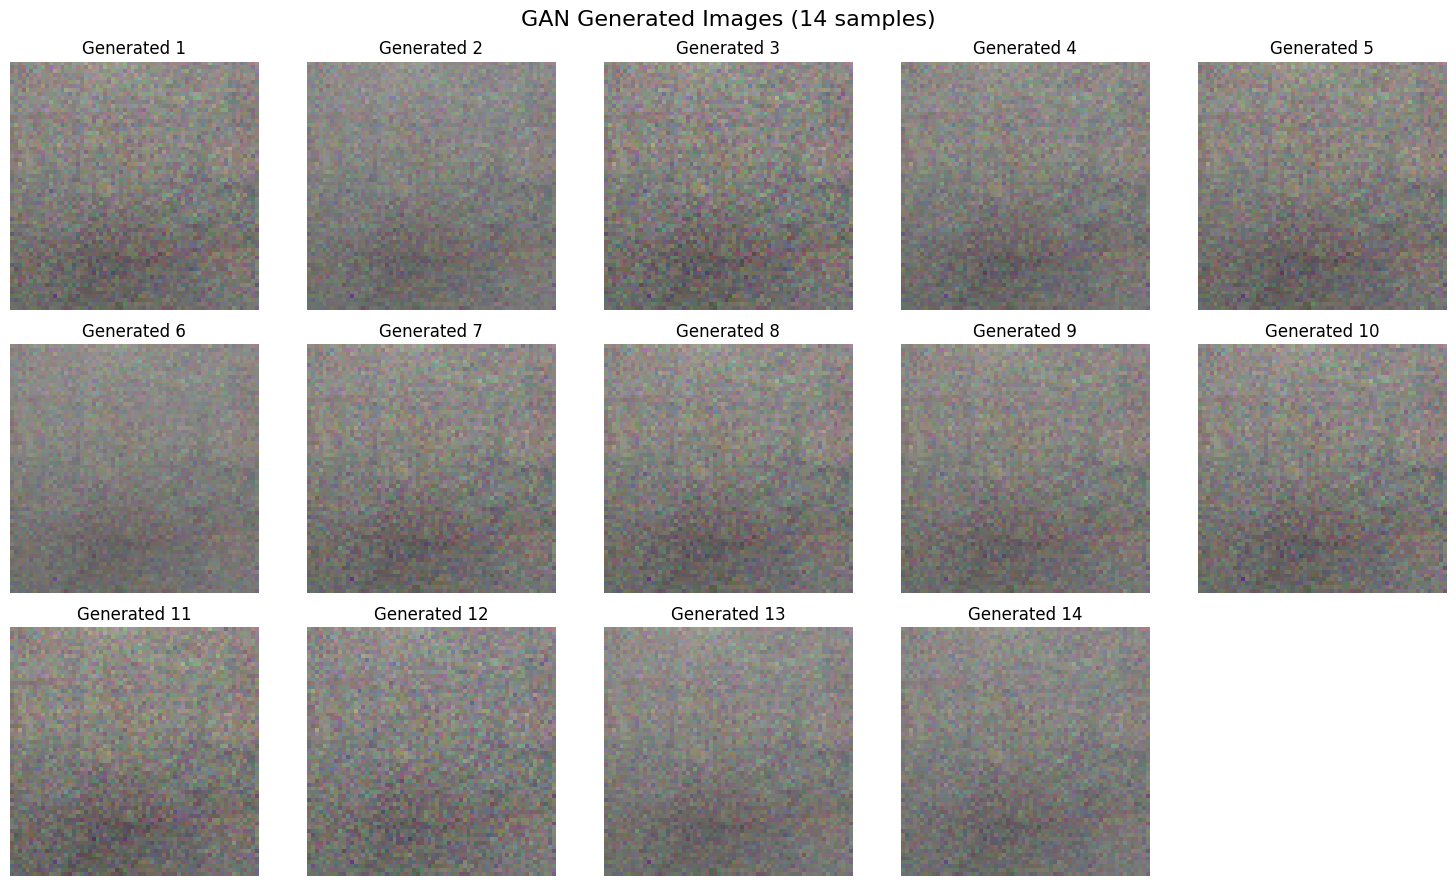

Generated 14 images and saved to 'generated_images'


In [10]:
from __future__ import print_function
import argparse
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.autograd import Variable
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration for image generation ---
# These values are set directly for notebook execution, replacing argparse.
config_path = 'samples/generator_config.json' # Path to the generator config saved by the training script
# weights_path = f'samples/netG_epoch_{epoch}.pth' # Path to the generator weights, using the last trained epoch
output_dir = 'generated_images' # Directory to save generated images
nimages_to_generate = 14 # Number of images the user wants to visualize
use_cuda = torch.cuda.is_available() # Check if CUDA is available

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load generator configuration
with open(config_path, 'r') as gencfg:
    generator_config = json.loads(gencfg.read())

imageSize = generator_config["imageSize"]
nz = generator_config["nz"]
nc = generator_config["nc"]
ngf = generator_config["ngf"]
noBN = generator_config["noBN"]
ngpu = generator_config["ngpu"]
mlp_G = generator_config["mlp_G"]
n_extra_layers = generator_config["n_extra_layers"]

# Define generator model based on config
# Assuming DCGAN_G, DCGAN_G_nobn, MLP_G are defined in previous cells
# We're reusing the 'netG' instance that was already created and potentially trained in a previous cell.
# If you run this cell independently without running the training cell, you might need to uncomment the following lines
# to re-initialize and load weights.
# if noBN:
#     netG = DCGAN_G_nobn(imageSize, nz, nc, ngf, ngpu, n_extra_layers)
# elif mlp_G:
#     netG = MLP_G(imageSize, nz, nc, ngf, ngpu)
# else:
#     netG = DCGAN_G(imageSize, nz, nc, ngf, ngpu, n_extra_layers)

# If netG was already trained in this session, it holds the trained weights.
# Otherwise, uncomment the line below to load from file (ensure weights_path is defined and valid).
# netG.load_state_dict(torch.load(weights_path, map_location=torch.device('cpu')))

# Move model to GPU if CUDA is enabled
if use_cuda:
    netG.cuda()

# Initialize noise vector
fixed_noise = torch.FloatTensor(nimages_to_generate, nz, 1, 1).normal_(0, 1)

# Move noise to GPU if CUDA is enabled
if use_cuda:
    fixed_noise = fixed_noise.cuda()

# Generate images
netG.eval() # Set generator to evaluation mode
with torch.no_grad(): # Disable gradient calculation for inference
    fake = netG(fixed_noise)
    fake.data = fake.data.mul(0.5).add(0.5) # De-normalize to [0, 1] range

# --- Visualization ---
# Determine grid size for subplots to accommodate all generated images
num_cols = 5
num_rows = (nimages_to_generate + num_cols - 1) // num_cols # Calculate ceiling division for rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, num_rows * 3))
axes = axes.flatten()

for i in range(nimages_to_generate):
    img = fake.data[i].cpu().numpy()      # (nc, H, W) - move to CPU and convert to numpy
    img = np.transpose(img, (1, 2, 0))    # (H, W, nc) - transpose dimensions for matplotlib
    img = np.clip(img, 0, 1) # Ensure values are within [0, 1] for display

    if img.shape[2] == 1:                 # grayscale image
        axes[i].imshow(img.squeeze(), cmap='gray')
    else:                                 # RGB image
        axes[i].imshow(img)

    axes[i].axis('off') # Hide axes ticks and labels
    axes[i].set_title(f'Generated {i+1}')

# Hide any unused subplots if the grid is larger than nimages_to_generate
for j in range(nimages_to_generate, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'GAN Generated Images ({nimages_to_generate} samples)', fontsize=16)
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Optionally save generated images to the output directory
for i in range(nimages_to_generate):
    vutils.save_image(fake.data[i], os.path.join(output_dir, f'generated_sample_{i+1}.png'))
print(f"Generated {nimages_to_generate} images and saved to '{output_dir}'")
